In [1]:
import torch
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda:0


# 加载数据集 归一化 标准化 创建dataset

In [2]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# 定义数据预处理和转换操作
# 将图像转换为Tensor格式，便于处理
# 归一化操作：将数据缩放到[-1, 1]之间
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为Tensor，包含归一化操作
    transforms.Normalize((0.2860,), (0.3530,))  #均值和标准差
])

# 导入Fashion MNIST数据集
train_dataset = datasets.FashionMNIST(
    root='data',
     train=True,
     download=None,
     transform=transform
     )
test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
     download=None,
     transform=transform
     )


# 创建dataload

In [3]:
from torch.utils.data import DataLoader

# 定义训练集和测试集的DataLoader
train_loader = DataLoader(  # 创建训练集的DataLoader
    dataset=train_dataset,  # 指定训练数据集
    batch_size=32,  # 设置每个批次的样本数量为64
    shuffle=True)  # 在每个epoch开始之前打乱训练数据

test_loader = DataLoader(  # 创建测试集的DataLoader
    dataset=test_dataset,  # 指定测试数据集
    batch_size=32,  # 设置每个批次的样本数量为64
    shuffle=False  # 测试数据不需要打乱
)  

# 创建模型

In [4]:
import torch.nn as nn

class CNN_FashionMNIST(nn.Module):
    def __init__(self):
        super(CNN_FashionMNIST, self).__init__()
        # 输入为1通道，形状为28x28

        # 第一组卷积
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)  # 28x28
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1) # 28x28
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # 池化 变成14x14

        # 第二组卷积
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # 14x14
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1) # 14x14
        #self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) #池化 变成7x7
        # 第三组卷积
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) # 7x7
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1) # 7x7
        #池化 变成3x3
        # 展平
        # 池化后输出 (128, 3, 3) → 128*3*3=1152
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)  # 10类

        self.relu = nn.ReLU()

    def forward(self, x):
        # 第一组卷积+池化
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # 第二组卷积+池化
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)#可以重复使用池化层，反正定义都一样

        # 第三组卷积+池化
        x = self.relu(self.conv5(x))
        x = self.relu(self.conv6(x))
        x = self.pool(x)

        x = torch.flatten(x, 1)  # 展平成(batch, -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型实例
model1 = CNN_FashionMNIST()




# 训练模型

In [5]:

import sys
sys.path.append('../day18')
import my_train2

import torch.optim as optim

# 1. 损失函数
criterion = nn.CrossEntropyLoss()

# 2. 优化器
optimizer = optim.Adam(model1.parameters(), lr=0.001)

# 3. 早停对象
early_stopping = my_train2.EarlyStopping(
    patience=5, 
    monitor='val_acc', 
    mode='max', 
    verbose=True
    )
# 4. 保存模型对象
# model_checkpoint = my_train2.ModelCheckpoint(
#     filepath='best_dnn_model.pth', 
#     monitor='val_acc', 
#     mode='max',
#     verbose=True, 
#     save_best_only=True
# )

# 假设之前已定义 train_loader, val_loader, device
# 如果未定义，请根据自己的环境做相应调整

trainer = my_train2.ModelTrainer(
    model=model1,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    early_stopping=early_stopping,
    eval_step=500
)

# 开始训练
trainer.train(num_epochs=20)



[Step 500] Val Loss: 0.4470 Val Acc: 0.8325
EarlyStopping: val_acc improved to 0.832500, reset patience.
[Step 1000] Val Loss: 0.3526 Val Acc: 0.8753
EarlyStopping: val_acc improved to 0.875300, reset patience.
[Step 1500] Val Loss: 0.3320 Val Acc: 0.8793
EarlyStopping: val_acc did not improve. Patience 1/5
Epoch [1/20], running_loss: 0.4474, running_acc: 0.84
[Step 2000] Val Loss: 0.2949 Val Acc: 0.8936
EarlyStopping: val_acc improved to 0.893600, reset patience.
[Step 2500] Val Loss: 0.2788 Val Acc: 0.8954
EarlyStopping: val_acc did not improve. Patience 1/5
[Step 3000] Val Loss: 0.2908 Val Acc: 0.8939
EarlyStopping: val_acc did not improve. Patience 2/5
[Step 3500] Val Loss: 0.2875 Val Acc: 0.8956
EarlyStopping: val_acc did not improve. Patience 3/5
Epoch [2/20], running_loss: 0.2727, running_acc: 0.90
[Step 4000] Val Loss: 0.2563 Val Acc: 0.9078
EarlyStopping: val_acc improved to 0.907800, reset patience.
[Step 4500] Val Loss: 0.2591 Val Acc: 0.9073
EarlyStopping: val_acc did not i

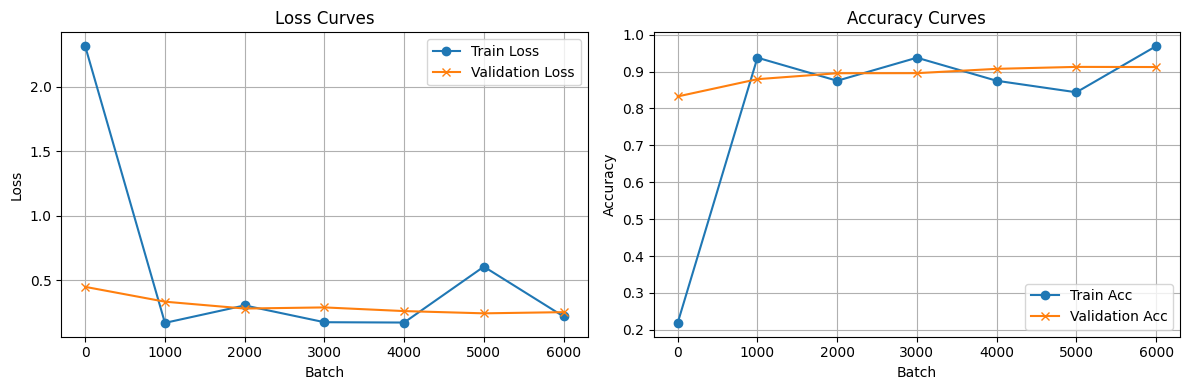

In [6]:
trainer.plot_curves()